# 비교, 마스크, 불리언 논리

이번 장에서는 NumPy 배열 내의 값을 검사하고 조작하기 위해 불리언 마스크를 사용하는 방법을 다룹니다.
마스킹은 일부 기준에 따라 배열의 값을 추출, 수정, 계산 또는 조작하려는 경우에 발생하게 됩니다. 예를 들어 특정 값보다 큰 모든 값을 계산하거나 일부 임계값을 초과하는 모든 이상값을 제거합니다.
NumPy에서 불리언 마스킹은 이러한 유형의 작업을 수행하는 가장 효율적인 방법인 경우가 많습니다.

## 예: 비오는 날 계산

특정 도시에서 1년 동안 매일 강수량을 나타내는 일련의 데이터가 있다고 가정해 보세요.
예를 들어 여기서는 Pandas를 사용하여 2015년 시애틀 시의 일일 강수량 통계를 불러옵니다([파트 3](03.00-Introduction-to-Pandas.ipynb) 참조).

In [1]:
import numpy as np
from vega_datasets import data

# Use DataFrame operations to extract rainfall as a NumPy array
rainfall_mm = np.array(
    data.seattle_weather().set_index('date')['precipitation']['2015'])
len(rainfall_mm)

365

배열에는 2015년 1월 1일부터 12월 31일까지의 일일 강우량을 밀리미터 단위로 제공하는 365개의 데이터가 들어 있습니다.

첫 번째 빠른 시각화 수단으로 Matplotlib를 사용하여 생성된 다음 그림에서 비오는 날의 히스토그램을 살펴보겠습니다(이 도구는 [4부](04.00-Introduction-To-Matplotlib.ipynb)에서 더 자세히 살펴보겠습니다).

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')

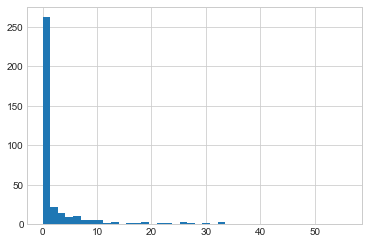

In [3]:
plt.hist(rainfall_mm, 40);

이 히스토그램은 데이터가 어떤 모양인지에 대한 일반적인 인상을 줍니다. 도시에 비가 많이 온다는 평판에도 불구하고 2015년에는 시애틀의 대부분의 날에 강수량이 거의 0에 가까웠습니다.
그러나 이는 우리가 보고 싶은 일부 정보를 제대로 전달하지 못합니다. 예를 들어 일년에 비가 오는 날이 몇 번이나 있었습니까? 그 비오는 날의 평균 강수량은 얼마였습니까? 강수량이 10mm를 넘는 날은 며칠입니까?

이에 대한 한 가지 접근 방식은 이러한 질문에 직접 대답하는 것입니다. 즉, 원하는 범위의 값을 볼 때마다 카운터를 증가시키면서 데이터를 반복합니다.
그러나 이 장 전체에서 논의한 이유로 이러한 접근 방식은 코드 작성 시간과 결과 계산 시간 측면에서 매우 비효율적입니다.
우리는 [NumPy 배열 계산: 범용 함수](02.03-Computation-on-arrays-ufuncs.ipynb)에서 NumPy의 ufunc를 루프 대신 사용하여 배열에 대한 빠른 요소별 산술 연산을 수행할 수 있음을 알아보았습니다. 같은 방식으로 다른 ufunc를 사용하여 배열에 대한 요소별 *비교*를 수행한 다음 결과를 조작하여 우리가 가진 질문에 답합니다.
지금은 데이터를 제쳐두고 이러한 유형의 질문에 신속하게 답하기 위해 *마스킹*을 사용하는 NumPy의 몇 가지 일반 도구를 살펴보겠습니다.

## Ufuncs로서의 비교 연산자

[NumPy 배열 계산: 범용 함수](02.03-Computation-on-arrays-ufuncs.ipynb)에서는 ufunc를 소개하고 산술 연산자에 중점을 두었습니다. 배열에 `+`, `-`, `*`, `/` 및 기타 연산자를 사용하면 요소별 작업이 수행된다는 것을 알아보았습니다.
NumPy는 또한 `<`(보다 작음) 및 `>`(보다 큼)과 같은 비교 연산자를 요소별 ufunc로 구현하고 있습니다.
이러한 비교 연산자의 결과는 항상 불리언 데이터 유형의 배열입니다.
6가지 표준 비교 작업을 모두 활용하면 됩니다.

In [4]:
x = np.array([1, 2, 3, 4, 5])

In [5]:
x < 3  # less than

array([ True,  True, False, False, False])

In [6]:
x > 3  # greater than

array([False, False, False,  True,  True])

In [7]:
x <= 3  # less than or equal

array([ True,  True,  True, False, False])

In [8]:
x >= 3  # greater than or equal

array([False, False,  True,  True,  True])

In [9]:
x != 3  # not equal

array([ True,  True, False,  True,  True])

In [10]:
x == 3  # equal

array([False, False,  True, False, False])

두 배열의 요소별 비교를 수행하고 복합 표현식을 포함하는 것도 가능합니다.

In [11]:
(2 * x) == (x ** 2)

array([False,  True, False, False, False])

산술 연산자의 경우와 마찬가지로 비교 연산자도 NumPy에서 ufunc로 구현됩니다. 예를 들어 `x < 3`이라고 쓰면 NumPy는 내부적으로 `np.less(x, 3)`를 사용합니다.
비교 연산자와 이에 상응하는 ufunc에 대한 요약은 다음과 같습니다.

| 운영자 | 동등한 ufunc | 운영자 | 동등한 ufunc |
|-------------|------|------------|------|
|`==` |`np.equal` |`!=` |`np.not_equal` |
|`<` |`np.less` |`<=` |`np.less_equal` |
|`>` |`np.greater` |`>=` |`np.greater_equal`|

산술 ufunc의 경우와 마찬가지로 이는 모든 크기와 모양의 배열에서 작동하며,
다음은 2차원 예입니다.

In [12]:
rng = np.random.default_rng(seed=1701)
x = rng.integers(10, size=(3, 4))
x

array([[9, 4, 0, 3],
       [8, 6, 3, 1],
       [3, 7, 4, 0]])

In [13]:
x < 6

array([[False,  True,  True,  True],
       [False, False,  True,  True],
       [ True, False,  True,  True]])

각각의 경우 결과는 불리언 배열이며 NumPy는 이러한 불리언 결과를 처리하기 위한 여러 가지 간단한 패턴이 있습니다.

## 불리언 배열 작업

불리언 배열이 주어지면 수행할 수 있는 다양한 작업을 수행합니다.
앞서 만든 2차원 배열 `x`를 사용하여 활용해 보겠습니다.

In [14]:
print(x)

[[9 4 0 3]
 [8 6 3 1]
 [3 7 4 0]]


### 요소 개수 세기

불리언 배열의 `True` 항목 수를 계산하려면 `np.count_nonzero`가 유용합니다.

In [15]:
# how many values less than 6?
np.count_nonzero(x < 6)

8

6보다 작은 배열 항목이 8개 있다는 것을 확인합니다.
이 정보를 얻는 또 다른 방법은 `np.sum`을 사용하는 것입니다. 이 경우 'False'는 '0'으로 간주되고 'True'는 '1'로 해석됩니다.

In [16]:
np.sum(x < 6)

8

`np.sum`의 장점 중 하나는 다른 NumPy 집계 함수와 마찬가지로 이 합계가 행이나 열에서도 수행될 수 있다는 것입니다.

In [17]:
# how many values less than 6 in each row?
np.sum(x < 6, axis=1)

array([3, 2, 3])

이는 행렬의 각 행에서 6보다 작은 값의 수를 세어 줍니다.

값 중 일부 또는 전부가 `True`인지 빠르게 확인하려면 (예상하셨겠지만) `np.any` 또는 `np.all`을 활용하면 됩니다.

In [18]:
# are there any values greater than 8?
np.any(x > 8)

True

In [19]:
# are there any values less than zero?
np.any(x < 0)

False

In [20]:
# are all values less than 10?
np.all(x < 10)

True

In [21]:
# are all values equal to 6?
np.all(x == 6)

False

`np.all` 및 `np.any`는 특정 축에서도 활용하면 됩니다. 예를 들어:

In [22]:
# are all values in each row less than 8?
np.all(x < 8, axis=1)

array([False, False,  True])

여기서 세 번째 행의 모든 ​​요소는 8보다 작지만 다른 행의 경우에는 그렇지 않습니다.

마지막으로 빠른 경고: [집계: 최소, 최대 및 그 사이의 모든 것](02.04-Computation-on-arrays-aggregates.ipynb)에서 언급한 대로 파이썬(Python)에는 `sum`, `any` 및 `all` 함수가 내장되어 있습니다. 이는 NumPy 버전과 구문이 다르며 특히 다차원 배열에 사용될 때 실패하거나 의도하지 않은 결과를 생성합니다. 이 예제에서는 `np.sum`, `np.any` 및 `np.all`을 사용하고 있는지 확인하세요!

### 불리언 연산자

우리는 이미 비가 20mm 미만인 날 또는 비가 10mm 이상인 날을 계산하는 방법을 살펴보았습니다.
하지만 비가 10mm 이상, 20mm 미만인 날이 며칠인지 알고 싶다면 어떻게 해야 할까요? 파이썬(Python)의 *비트 논리 연산자*, `&`, `|`, `^` 및 `~`를 사용하여 이를 수행합니다.
표준 산술 연산자와 마찬가지로 NumPy는 이를 (보통 불리언) 배열에서 요소별로 작동하는 ufunc로 오버로드합니다.

예를 들어 이러한 종류의 복합 질문을 다음과 같이 해결합니다.

In [23]:
np.sum((rainfall_mm > 10) & (rainfall_mm < 20))

16

이는 16일 동안 10~20mm의 강수량이 있었음을 알려줍니다.

여기서 괄호가 중요합니다. 연산자 우선순위 규칙으로 인해 괄호를 제거하면 이 표현식은 다음과 같이 평가되어 오류가 발생하게 됩니다.

``파이썬
강수량_mm > (10 & 강수량_mm) < 20
````

좀 더 복잡한 표현을 보여드리겠습니다. De Morgan의 법칙을 사용하면 동일한 결과를 다른 방식으로 계산합니다.

In [24]:
np.sum(~( (rainfall_mm <= 10) | (rainfall_mm >= 20) ))

16

배열에서 비교 연산자와 불리언 연산자를 조합하면 광범위하고 효율적인 논리 연산이 가능해집니다.

다음 표에는 비트 불리언 연산자와 해당 ufunc가 요약되어 있습니다.

| 운영자 | 동등한 ufunc | 운영자 | 동등한 ufunc |
|-------------|------|-------------|------|
|`&` |`np.bitwise_and` |&#124;       |`np.bitwise_or` |
|`^` |`np.bitwise_xor` |`~` |`np.bitwise_not` |

이러한 도구를 사용하면 날씨 데이터에 관해 가질 수 있는 많은 질문에 답합니다.
다음은 마스킹과 집계를 결합할 때 계산할 수 있는 결과의 몇 가지 예입니다.

In [25]:
print("Number days without rain:  ", np.sum(rainfall_mm == 0))
print("Number days with rain:     ", np.sum(rainfall_mm != 0))
print("Days with more than 10 mm: ", np.sum(rainfall_mm > 10))
print("Rainy days with < 5 mm:    ", np.sum((rainfall_mm > 0) &
                                            (rainfall_mm < 5)))

Number days without rain:   221
Number days with rain:      144
Days with more than 10 mm:  34
Rainy days with < 5 mm:     83


## 불리언 배열을 마스크로 사용

이전 섹션에서는 불리언 배열에서 직접 계산된 집계를 살펴보았습니다.
더 강력한 패턴은 불리언 배열을 마스크로 사용하여 데이터 자체의 특정 하위 집합을 추출하는 것입니다. 이전의 `x` 배열로 돌아가 보겠습니다.

In [26]:
x

array([[9, 4, 0, 3],
       [8, 6, 3, 1],
       [3, 7, 4, 0]])

예를 들어 5보다 작은 배열의 모든 값으로 구성된 배열을 추출하고 싶다고 가정해 봅시다. 이미 본 것처럼 이 조건에 대한 불리언 배열을 쉽게 얻을 수 있습니다.

In [27]:
x < 5

array([[False,  True,  True,  True],
       [False, False,  True,  True],
       [ True, False,  True,  True]])

이제 배열에서 이러한 값을 *선택*하려면 이 불리언 배열에서 인덱싱하면 됩니다. 이를 *마스킹* 작업이라고 합니다.

In [28]:
x[x < 5]

array([4, 0, 3, 3, 1, 3, 4, 0])

반환되는 것은 이 조건을 만족하는 모든 값으로 채워진 1차원 배열입니다. 즉, 마스크 배열이 `True`인 위치의 모든 값입니다.

그런 다음 우리는 원하는 대로 이러한 가치를 자유롭게 처리합니다.
예를 들어 시애틀 강우 데이터에 대한 몇 가지 관련 통계를 계산합니다.

In [29]:
# construct a mask of all rainy days
rainy = (rainfall_mm > 0)

# construct a mask of all summer days (June 21st is the 172nd day)
days = np.arange(365)
summer = (days > 172) & (days < 262)

print("Median precip on rainy days in 2015 (mm):   ",
      np.median(rainfall_mm[rainy]))
print("Median precip on summer days in 2015 (mm):  ",
      np.median(rainfall_mm[summer]))
print("Maximum precip on summer days in 2015 (mm): ",
      np.max(rainfall_mm[summer]))
print("Median precip on non-summer rainy days (mm):",
      np.median(rainfall_mm[rainy & ~summer]))

Median precip on rainy days in 2015 (mm):    3.8
Median precip on summer days in 2015 (mm):   0.0
Maximum precip on summer days in 2015 (mm):  32.5
Median precip on non-summer rainy days (mm): 4.1


불리언 연산, 마스킹 연산 및 집계를 결합함으로써 데이터 세트에 대한 이러한 종류의 질문에 매우 빠르게 답합니다.

## 키워드 및/또는 연산자 비교 &/|

자주 헷갈리는 부분은 키워드 `and`와 `or`와 연산자 `&`와 `|` 사이의 차이입니다.
각각 언제 사용해야 할까요?

차이점은 다음과 같습니다. `and`와 `or`는 객체 전체를 대상으로 하지만, `&`와 `|`는 객체 내의 요소에 대해 작동하며,

`and` 또는 `or`를 사용하는 것은 파이썬(Python)에게 객체를 단일 불리언 엔터티로 처리하도록 요청하는 셈입니다.
파이썬(Python)에서는 0이 아닌 모든 정수가 'True'로 평가됩니다. 따라서:

In [30]:
bool(42), bool(0)

(True, False)

In [31]:
bool(42 and 0)

False

In [32]:
bool(42 or 0)

True

정수에 `&` 및 `|`를 사용하면 표현식은 요소의 비트 표현에 기준으로 작동하며 숫자를 구성하는 개별 비트에 *and* 또는 *or*를 적용합니다.

In [33]:
bin(42)

'0b101010'

In [34]:
bin(59)

'0b111011'

In [35]:
bin(42 & 59)

'0b101010'

In [36]:
bin(42 | 59)

'0b111011'

결과를 산출하기 위해 이진 표현의 해당 비트가 비교됨을 알 수 있습니다.

NumPy에 불리언 값의 배열이 있는 경우 이는 `1 = True` 및 `0 = False`인 비트 문자열로 간주할 수 있으며 `&` 및 `|`는 이전 예와 유사하게 작동하며,

In [37]:
A = np.array([1, 0, 1, 0, 1, 0], dtype=bool)
B = np.array([1, 1, 1, 0, 1, 1], dtype=bool)
A | B

array([ True,  True,  True, False,  True,  True])

그러나 이러한 배열에 'or'를 사용하면 잘 정의된 값이 아닌 전체 배열 개체의 참 또는 거짓을 평가하려고 시도하기 때문입니다.

In [38]:
A or B

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

마찬가지로, 주어진 배열에서 불리언 표현식을 평가할 때 `or` 또는 `and` 대신 `|` 또는 `&`를 사용해야 합니다.

In [39]:
x = np.arange(10)
(x > 4) & (x < 8)

array([False, False, False, False, False,  True,  True,  True, False,
       False])

전체 배열의 참 또는 거짓을 평가하려고 하면 이전에 본 것과 동일한 'ValueError'가 발생하게 됩니다.

In [40]:
(x > 4) and (x < 8)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

따라서 이것을 기억하십시오: `and`와 `or`는 전체 객체에 대해 단일 불리언 평가를 수행하는 반면 `&`와 `|`는 객체의 내용(개별 비트 또는 바이트)에 대해 여러 불리언 평가를 수행합니다.
Boolean NumPy 배열의 경우 후자가 대부분의 상황에서 적절한 방식입니다.